In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

# 1. LOAD DATASETS
# Ensure these files are in your working directory
train = pd.read_csv('/content/train_LZdllcl.csv')
test = pd.read_csv('/content/test_2umaH9m.csv')
sample_sub = pd.read_csv('/content/sample_submission_M0L0uXE.csv')

train.info()
test.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB
<class 'panda

In [8]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("Checking for Missing Values in Train:\n", train.isnull().sum())
print("\nTarget Distribution:\n", train['is_promoted'].value_counts(normalize=True))



Checking for Missing Values in Train:
 employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

Target Distribution:
 is_promoted
0    0.91483
1    0.08517
Name: proportion, dtype: float64


In [9]:
print("Checking for Missing Values in Train:\n", test.isnull().sum())

Checking for Missing Values in Train:
 employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


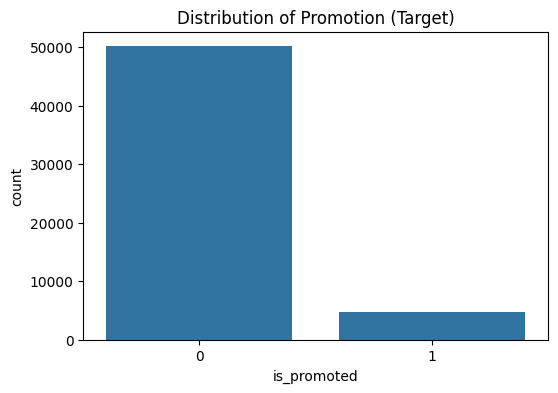

In [10]:
# Visualizing the imbalance

plt.figure(figsize=(6,4))
sns.countplot(x='is_promoted', data=train)
plt.title('Distribution of Promotion (Target)')
plt.show()



In [11]:
# 3. PRE-PROCESSING (Handled Separately)
def preprocess_dataset(df, is_train=True):
    df_copy = df.copy()

    # Impute missing values with Mode (Crucial: Do not remove rows)
    df_copy['education'] = df_copy['education'].fillna(df_copy['education'].mode()[0])
    df_copy['previous_year_rating'] = df_copy['previous_year_rating'].fillna(df_copy['previous_year_rating'].mode()[0])

    # Label Encoding categorical variables
    le = LabelEncoder()
    categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']
    for col in categorical_cols:
        df_copy[col] = le.fit_transform(df_copy[col])

    return df_copy

# Processing datasets separately as instructed
train_processed = preprocess_dataset(train)
test_processed = preprocess_dataset(test)



In [12]:
# 4. MODELLING
# Splitting features and target
X = train_processed.drop(columns=['employee_id', 'is_promoted'])
y = train_processed['is_promoted']

# Internal Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Using HistGradientBoosting (Robust for tabular data and imbalanced classes)
model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)



HistGradientBoostingClassifier(max_iter=300, random_state=42)

In [13]:
# 5. FINE TUNING (Threshold Optimization for F1 Score)
# Since the metric is F1, we find the best probability threshold
val_probs = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

# Calculate F1 Score for all possible thresholds

f1_scores = np.divide(2 * precisions * recalls, precisions + recalls,
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"\nOptimal Threshold: {best_threshold:.4f}")
print(f"Best Validation F1 Score: {np.max(f1_scores):.4f}")




Optimal Threshold: 0.2883
Best Validation F1 Score: 0.5392


In [14]:
# 6. FINAL PREDICTION & SUBMISSION PREPARATION
# Applying the model to the test dataset
X_test = test_processed.drop(columns=['employee_id'])
test_probs = model.predict_proba(X_test)[:, 1]

# Apply the optimal threshold to get final binary predictions
final_preds = (test_probs >= best_threshold).astype(int)

# Replacing values in the sample submission template
submission = sample_sub.copy()
submission['is_promoted'] = final_preds

# 7. SAVE AS CSV
submission.to_csv('final_submission_wns_wizard.csv', index=False)
print("\nFinal submission file 'final_submission_wns_wizard.csv' has been saved.")


Final submission file 'final_submission_wns_wizard.csv' has been saved.
